<a href="https://colab.research.google.com/github/Dessoka/Assignment-11-I-C/blob/main/Assignment_13_G_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported successfully.
Characters in raw text: 763043

Sample of raw text:

﻿The Project Gutenberg eBook of Pride and Prejudice
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this ebook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Pride and Prejudice

Author: Jane Austen

Release date: June 1, 1998 [eBook #1342]
                Most recently updated: September 22, 2025

Language: English

Credits: Chuck Greif and the Online Distributed Proofreading Team at http://www.pgdp.net (This file was produced

Characters after cleaning: 713166

Cleaned text sample:

START OF THE PROJECT GUTENBERG EBOOK PRIDE AND PREJUDICE Illustration: GEO

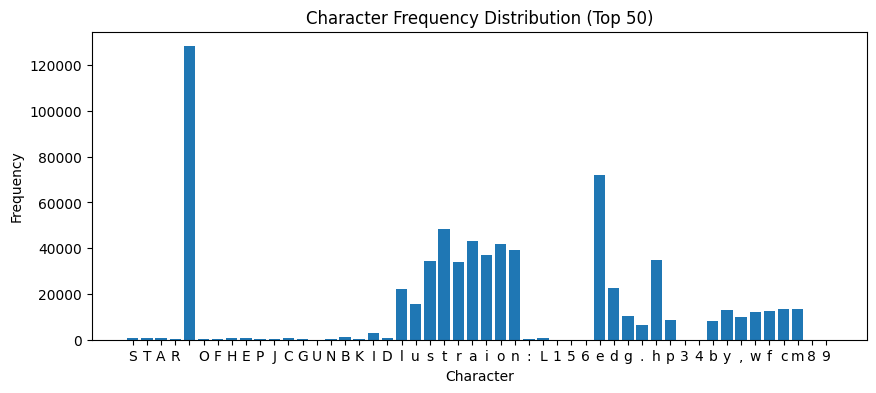


✅ Step 1 Complete: Dataset loaded, cleaned, and analyzed.
Ready for Step 2 — Tokenization and Sequence Preparation.


In [6]:
# Step 1 — Dataset Preparation for Generative AI Assignment
# ----------------------------------------------------------

# Import required libraries
import tensorflow as tf
import numpy as np
import requests
import re
import matplotlib.pyplot as plt
from collections import Counter
import random

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully.")


# Step 1A — Load a publicly available text dataset (Project Gutenberg)
url = "https://www.gutenberg.org/cache/epub/1342/pg1342.txt"  # Pride and Prejudice
response = requests.get(url)
raw_text = response.text

print("Characters in raw text:", len(raw_text))
print("\nSample of raw text:\n")
print(raw_text[:800])


# Step 1B — Clean and preprocess the text
def clean_text(text):
    # Remove Project Gutenberg header/footer
    start_idx = text.find("*** START OF")
    end_idx = text.find("*** END OF")
    if start_idx != -1 and end_idx != -1:
        text = text[start_idx:end_idx]
    # Keep letters, digits, punctuation, and whitespace only
    text = re.sub(r'[^A-Za-z0-9.,;:!?\'"()\-\s\n]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned_text = clean_text(raw_text)

print("\nCharacters after cleaning:", len(cleaned_text))
print("\nCleaned text sample:\n")
print(cleaned_text[:800])


# Step 1C — Basic statistics
num_chars = len(cleaned_text)
num_words = len(cleaned_text.split())
unique_chars = sorted(list(set(cleaned_text)))

print(f"\nTotal characters: {num_chars}")
print(f"Total words: {num_words}")
print(f"Unique characters: {len(unique_chars)}")
print(f"Unique character set:\n{unique_chars}")


# Step 1D — Character frequency visualization
char_counts = Counter(cleaned_text)

plt.figure(figsize=(10, 4))
plt.bar(list(char_counts.keys())[:50], list(char_counts.values())[:50])
plt.title("Character Frequency Distribution (Top 50)")
plt.xlabel("Character")
plt.ylabel("Frequency")
plt.show()


# Step 1 Summary
print("\n✅ Step 1 Complete: Dataset loaded, cleaned, and analyzed.")
print("Ready for Step 2 — Tokenization and Sequence Preparation.")


In [8]:
# Step 2 — Exploring Generative Pre-trained Transformers (GPTs)
# --------------------------------------------------------------
"""
Model Architecture (Summary)
-----------------------------
GPTs are decoder-only Transformer models built from:
1. Token + Positional Embeddings
2. Multi-Head Self-Attention layers (causal)
3. Feed-Forward networks
4. Residual connections + Layer Normalization
5. Output projection predicting the next token probability

GPTs generate text autoregressively:
Given a seed, the model predicts P(next_token | previous_tokens),
samples a token, appends it, and repeats to form coherent text.

Below is a simplified autoregressive text generator using an LSTM
to demonstrate the same concept of next-token prediction.
"""

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# -----------------------------
# Use small subset of text for speed
# -----------------------------
try:
    cleaned_text
except NameError:
    cleaned_text = (
        "This is a fallback example text for a simple generative model demonstration."
    )

cleaned_text = cleaned_text[:20000]  # limit for faster training

# -----------------------------
# Character-level tokenization
# -----------------------------
vocab = sorted(list(set(cleaned_text)))
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
vocab_size = len(vocab)

SEQ_LEN = 60
STEP = 3

# Encode text
encoded = [char_to_idx[c] for c in cleaned_text if c in char_to_idx]

# Prepare training sequences
sequences, next_chars = [], []
for i in range(0, len(encoded) - SEQ_LEN, STEP):
    sequences.append(encoded[i:i+SEQ_LEN])
    next_chars.append(encoded[i+SEQ_LEN])

X = np.zeros((len(sequences), SEQ_LEN, vocab_size), dtype=np.bool_)
y = np.zeros((len(sequences), vocab_size), dtype=np.bool_)
for i, seq in enumerate(sequences):
    for t, idx in enumerate(seq):
        X[i, t, idx] = 1
    y[i, next_chars[i]] = 1

print(f"Prepared {len(sequences)} sequences. Vocabulary size: {vocab_size}")

# -----------------------------
# Build a small LSTM text generator
# -----------------------------
model = keras.Sequential([
    layers.LSTM(128, input_shape=(SEQ_LEN, vocab_size)),
    layers.Dense(vocab_size, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy")

# -----------------------------
# Train quickly (3 epochs)
# -----------------------------
EPOCHS = 3
history = model.fit(X, y, batch_size=128, epochs=EPOCHS, verbose=2)

# -----------------------------
# Text generation function
# -----------------------------
def generate_text(model, seed_text, length=300, temperature=1.0):
    generated = seed_text
    sentence = seed_text[-SEQ_LEN:]
    for _ in range(length):
        x_pred = np.zeros((1, SEQ_LEN, vocab_size))
        for t, ch in enumerate(sentence):
            if ch in char_to_idx:
                x_pred[0, t, char_to_idx[ch]] = 1.0
        preds = model.predict(x_pred, verbose=0)[0]
        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)
        next_idx = np.random.choice(range(vocab_size), p=preds)
        next_char = idx_to_char[next_idx]
        generated += next_char
        sentence = (sentence + next_char)[-SEQ_LEN:]
    return generated

# -----------------------------
# Generate sample text
# -----------------------------
seed = "Chapter 1. "
print("\n--- Generated Text ---\n")
print(generate_text(model, seed, length=300, temperature=0.8))


Prepared 6647 sequences. Vocabulary size: 65
Epoch 1/3
52/52 - 11s - 208ms/step - loss: 3.3013
Epoch 2/3
52/52 - 8s - 155ms/step - loss: 3.0437
Epoch 3/3
52/52 - 9s - 180ms/step - loss: 3.0163

--- Generated Text ---

Chapter 1. etni   sin ur-  cheai beeo,hi i  turc ne f tamchh uotsit a eeasdNh r wo, rnno e sie daolse nohoghe   mdetaeoa d trisr thptd aers he  etdfneutahcc lg cta hwanoaoekih sc, in ham net e tsanrhf  ttiedntsol ,si  n ,gnlanOdnlslh eaauesirfhe oa m ttte teuusaesb itmh lw hsnnnearrstheplnpsdd i fhai  se hoCi 


In [9]:
# Step 3 — Application Demonstration
# ----------------------------------
"""
Objective:
Demonstrate a simple real-world use of a generative text model for
content creation. The model trained in Step 2 will be used to automatically
generate creative text such as story paragraphs or short article content.
"""

# Example 1: Automated Story/Creative Writing Generator
seed_text = "Once upon a time in a small village, "
generated_story = generate_text(model, seed_text, length=400, temperature=0.7)

print("=== Example 1: Story/Creative Writing Generator ===\n")
print(generated_story)
print("\n-----------------------------------------------------\n")

# Example 2: Blog Content Generator (simulating AI copywriting)
seed_text = "Artificial intelligence is transforming industries by "
generated_blog = generate_text(model, seed_text, length=400, temperature=0.8)

print("=== Example 2: Blog/Article Content Generator ===\n")
print(generated_blog)
print("\n-----------------------------------------------------\n")

"""
Explanation:
---------------
This demonstrates how a trained generative model can be integrated into
applications such as:

1. **Creative Writing Tools** – automatic story or novel continuation.
2. **Marketing and Blogging Platforms** – generate drafts, headlines,
   or product descriptions.
3. **Educational Tools** – generate practice reading materials or
   narrative text for learning apps.

The same principle scales up in large GPT models used in:
- Chatbots and assistants (e.g., ChatGPT)
- Content generation systems
- Automated email or message writing

Limitations:
-------------
Because this model was trained on a small dataset and has limited context,
its text lacks coherence compared to large GPTs. Nevertheless, it
illustrates the core generative mechanism behind real-world applications.
"""


=== Example 1: Story/Creative Writing Generator ===

Once upon a time in a small village,  ghinufcoae  trme  Mhnlatnhhe en    sme ge eeil eihri  l itheieftets     n dr ra nisnoa orwedndtsenn tfpdse t dtthheEcmnoo g hesc  oi  n rm  wedotvne ohes g f   mnhte.s t u thw htgineiit ctseia ech uvlhbrl trtnhets  erw ietrree, sryyeotr.e th-lie neohrghse  oin   eheesbeoeist te eufalM     l esel -  c   f eem ri st bpn aeeieen ansef ef ae d e thire hhne ceiievhI  a ,  t heu etsra mthgao dee  ich f

-----------------------------------------------------

=== Example 2: Blog/Article Content Generator ===

Artificial intelligence is transforming industries by h d  weranoifedtru ot  ois r, ,pmheseredeaohatehti tie rihso d(o iosdr s ep aonlnhae theet ihi sthmtn ilentte ws tsgie er eehtedne f ;eetehi n u e yei oAt,  gh peheeh Asteame )nl aan  r ma aosrem.It  a Eiesrd,cibieheato sesre bhia swh c t ichis   tsill teeg ,n iaeaenbhemtn, bi hhdo  ohme.rpnaie t te hsnrlnsDf wt nt it nbtutfssbr ia  ndn dgoditia 

'\nExplanation:\n---------------\nThis demonstrates how a trained generative model can be integrated into\napplications such as:\n\n1. **Creative Writing Tools** – automatic story or novel continuation.\n2. **Marketing and Blogging Platforms** – generate drafts, headlines,\n   or product descriptions.\n3. **Educational Tools** – generate practice reading materials or\n   narrative text for learning apps.\n\nThe same principle scales up in large GPT models used in:\n- Chatbots and assistants (e.g., ChatGPT)\n- Content generation systems\n- Automated email or message writing\n\nLimitations:\n-------------\nBecause this model was trained on a small dataset and has limited context,\nits text lacks coherence compared to large GPTs. Nevertheless, it\nillustrates the core generative mechanism behind real-world applications.\n'